# Dataset Overview 

* **Name:** Sleep Health and Lifestyle
* **Purpose:** Investigate how lifestyle and physiological factors relate to sleep outcomes (especially the *Sleep Disorder* label); suitable for EDA, classification, risk profiling, and health insights.
* **Target:** **Sleep Disorder** — typical classes: *None*, *Insomnia*, *Sleep Apnea*.
* **Structure:** Identifier (ID), demographics (gender, age, occupation), behavioral measures (sleep duration, steps, activity, stress), physiological measures (blood pressure, heart rate), and categorical health indicators (BMI Category).

---
# Features

| Feature                   | Type    | Unit / Scale                       | What it means                                                                                | Missing |
| ------------------------- | ------- | ---------------------------------- | -------------------------------------------------------------------------------------------- | ------- |
| `Person ID`               | Numeric | ID                                 | Unique identifier for each individual                                                        | 0       |
| `Gender`                  | Text    | Category                           | Self-reported gender (e.g., Male, Female)                                                    | 0       |
| `Age`                     | Numeric | Years                              | Age in years (typical range: 27–59)                                                          | 0       |
| `Occupation`              | Text    | Category                           | Primary job/occupation category (e.g., Nurse, Doctor, Engineer, Lawyer, Teacher, Accountant) | 0       |
| `Sleep Duration`          | Numeric | Hours                              | Average nightly sleep duration (typical range: 5.8–8.5)                                      | 0       |
| `Quality of Sleep`        | Numeric | Score (1–10)                       | Self-reported sleep quality (typical range: 4–9)                                             | 0       |
| `Physical Activity Level` | Numeric | Minutes/day                        | Daily physical activity amount (typical range: 30–90)                                        | 0       |
| `Stress Level`            | Numeric | Score (1–10)                       | Self-reported stress level (typical range: 3–8)                                              | 0       |
| `BMI Category`            | Text    | Category                           | Body-mass-index category (e.g., Normal, Overweight, Obese)                                   | 0       |
| `Blood Pressure`          | Text    | Systolic/Diastolic (mmHg, as text) | Resting blood pressure recorded as “systolic/diastolic” (e.g., 120/80, 130/85, 140/95)       | 0       |
| `Heart Rate`              | Numeric | Beats per minute                   | Resting heart rate (typical range: 65–86)                                                    | 0       |
| `Daily Steps`             | Numeric | Steps/day                          | Average number of steps per day (typical range: 3,000–10,000)                                | 0       |
| `Sleep Disorder`          | Text    | Label                              | Sleep disorder label (None, Insomnia, Sleep Apnea)                                           | 0       |

---


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/lifestyle-and-sleep-patterns/Sleep_health_and_lifestyle_dataset.csv


# STEP 1: DATA LOADING AND INITIAL EXPLORATION

In [2]:
# Load dataset
df = pd.read_csv('/kaggle/input/lifestyle-and-sleep-patterns/Sleep_health_and_lifestyle_dataset.csv')

print(f"Dataset dimensions: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

# Display basic information
print("\nDataset overview:")
print(df.info())

print("\nMissing values check:")
missing_summary = df.isnull().sum()
if missing_summary.sum() == 0:
    print("No missing values detected")
else:
    print(missing_summary[missing_summary > 0])

print("\nTarget variable distribution:")
target_dist = df['Sleep Disorder'].value_counts()
print(target_dist)
print(f"Target balance ratio: {target_dist.min() / target_dist.max():.3f}")


Dataset dimensions: 374 rows × 13 columns
Memory usage: 133.27 KB

Dataset overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 


# STEP 2: DATA PREPROCESSING AND FEATURE ENGINEERING

In [3]:
# Create working copy
data = df.copy()

# Extract blood pressure components
data[['Systolic_BP', 'Diastolic_BP']] = data['Blood Pressure'].str.split('/', expand=True).astype(int)

# Create derived features
data['BP_Ratio'] = data['Systolic_BP'] / data['Diastolic_BP']
data['Sleep_Efficiency'] = data['Quality of Sleep'] / data['Sleep Duration']
data['Activity_Per_Hour'] = data['Physical Activity Level'] / 24
data['Steps_Per_Activity'] = data['Daily Steps'] / (data['Physical Activity Level'] + 1)

# Create categorical features
data['Age_Category'] = pd.cut(data['Age'], 
                              bins=[0, 35, 45, 55, 100], 
                              labels=['Young_Adult', 'Middle_Age', 'Senior', 'Elder'])

data['BMI_Simplified'] = data['BMI Category'].replace({
    'Normal Weight': 'Normal',
    'Normal': 'Normal'
})

data['Risk_Profile'] = 'Low'
data.loc[(data['Stress Level'] >= 7) | (data['BMI_Simplified'] == 'Obese'), 'Risk_Profile'] = 'Medium'
data.loc[(data['Stress Level'] >= 8) & (data['BMI_Simplified'] == 'Obese'), 'Risk_Profile'] = 'High'

print("New features created:")
new_features = ['Systolic_BP', 'Diastolic_BP', 'BP_Ratio', 'Sleep_Efficiency', 
                'Activity_Per_Hour', 'Steps_Per_Activity', 'Age_Category', 'Risk_Profile']
for feature in new_features:
    print(f"  • {feature}")

print(f"\nDataset expanded to {data.shape[1]} features")

New features created:
  • Systolic_BP
  • Diastolic_BP
  • BP_Ratio
  • Sleep_Efficiency
  • Activity_Per_Hour
  • Steps_Per_Activity
  • Age_Category
  • Risk_Profile

Dataset expanded to 22 features


# STEP 3: EXPLORATORY DATA ANALYSIS

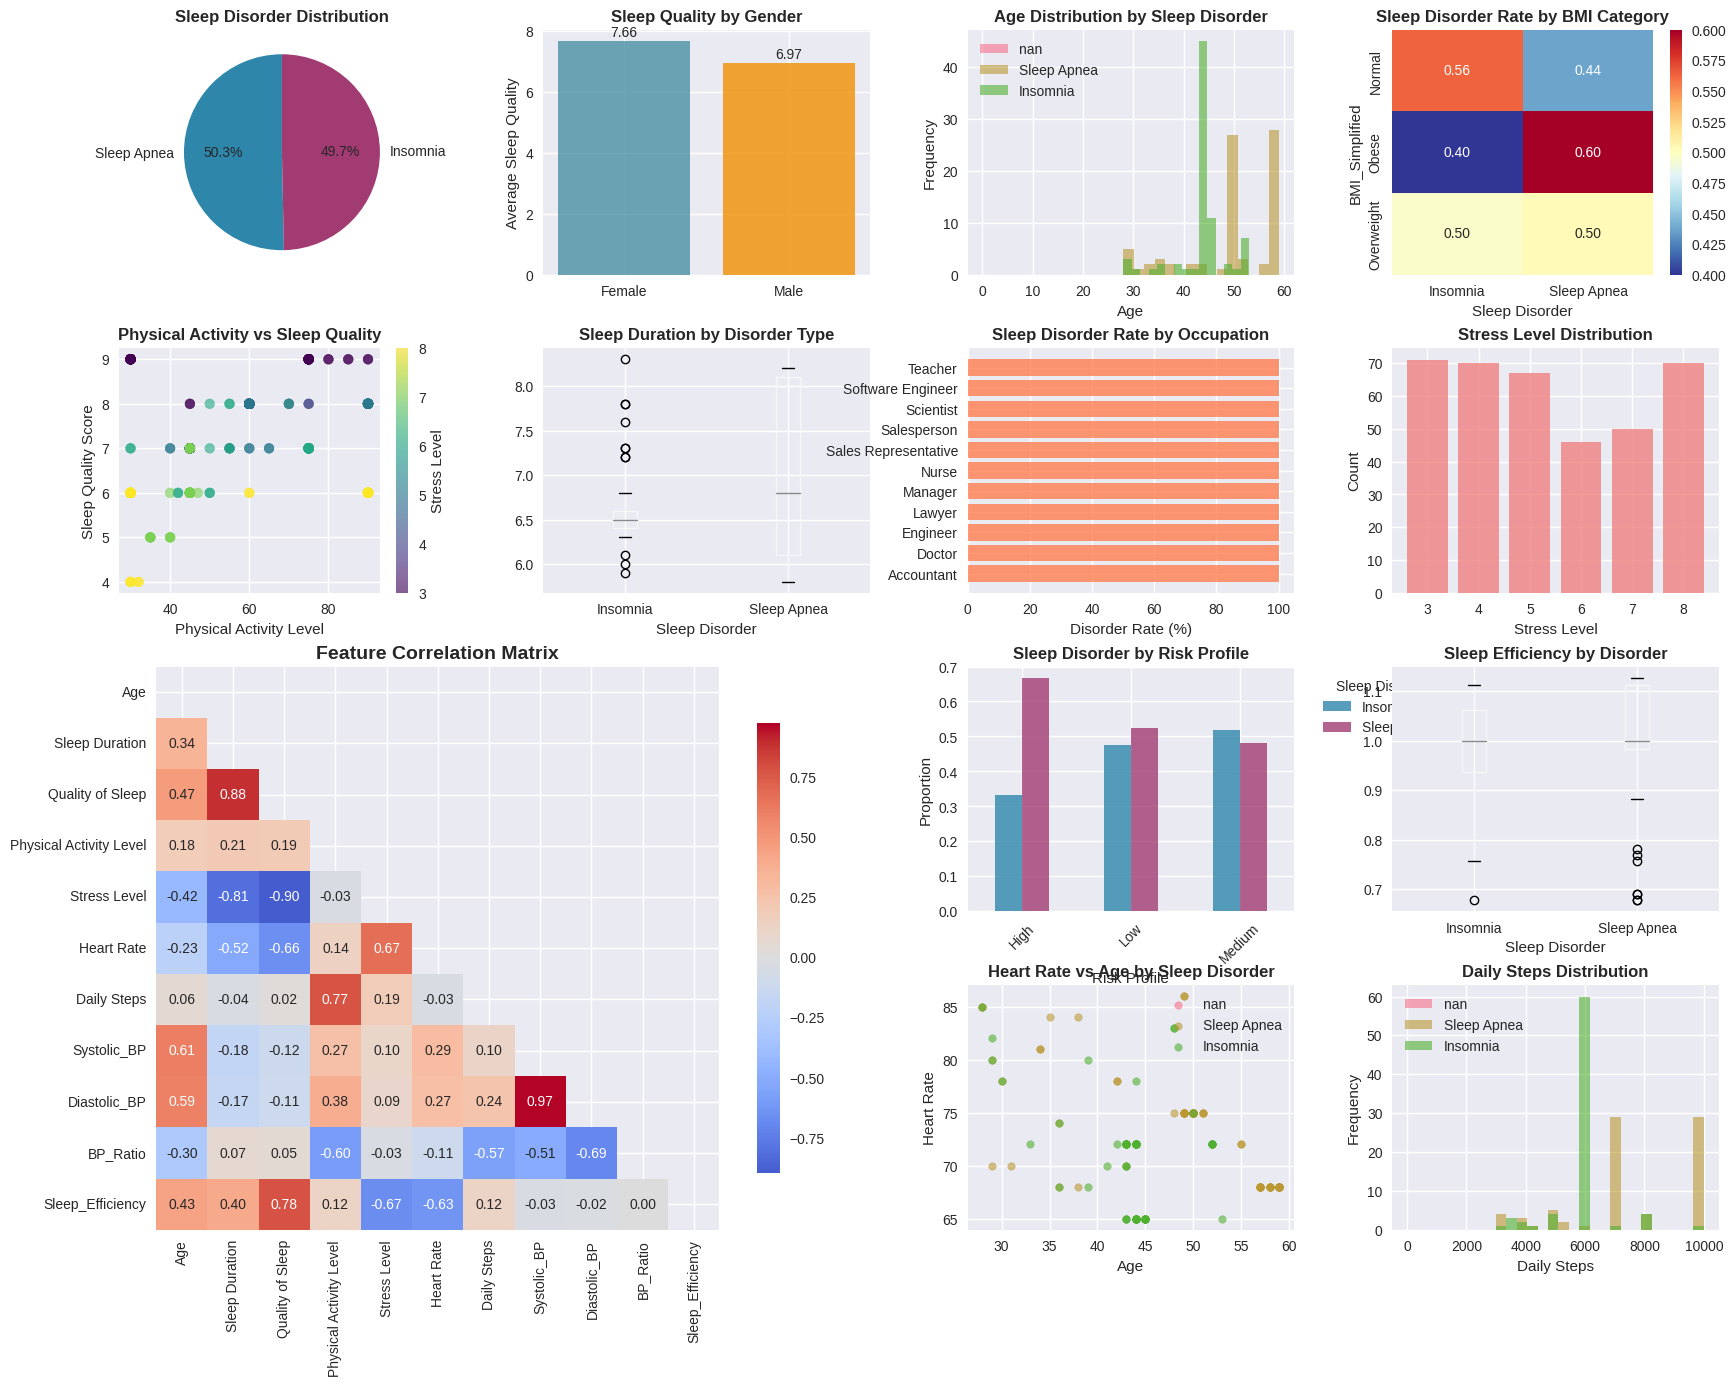

Correlation insights (|r| > 0.5):
  • Age ↔ Systolic_BP: 0.606
  • Age ↔ Diastolic_BP: 0.594
  • Sleep Duration ↔ Quality of Sleep: 0.883
  • Sleep Duration ↔ Stress Level: -0.811
  • Sleep Duration ↔ Heart Rate: -0.516
  • Quality of Sleep ↔ Stress Level: -0.899
  • Quality of Sleep ↔ Heart Rate: -0.660
  • Quality of Sleep ↔ Sleep_Efficiency: 0.782
  • Physical Activity Level ↔ Daily Steps: 0.773
  • Physical Activity Level ↔ BP_Ratio: -0.596
  • Stress Level ↔ Heart Rate: 0.670
  • Stress Level ↔ Sleep_Efficiency: -0.671
  • Heart Rate ↔ Sleep_Efficiency: -0.629
  • Daily Steps ↔ BP_Ratio: -0.570
  • Systolic_BP ↔ Diastolic_BP: 0.973
  • Systolic_BP ↔ BP_Ratio: -0.510
  • Diastolic_BP ↔ BP_Ratio: -0.694


In [4]:
# Create comprehensive visualization
fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(4, 4, hspace=0.3, wspace=0.3)

# Sleep disorder distribution
ax1 = fig.add_subplot(gs[0, 0])
disorder_counts = data['Sleep Disorder'].value_counts()
colors = ['#2E86AB', '#A23B72', '#F18F01']
wedges, texts, autotexts = ax1.pie(disorder_counts.values, labels=disorder_counts.index, 
                                   autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title('Sleep Disorder Distribution', fontsize=12, fontweight='bold')

# Gender vs Sleep Quality
ax2 = fig.add_subplot(gs[0, 1])
gender_sleep = data.groupby('Gender')['Quality of Sleep'].mean()
bars = ax2.bar(gender_sleep.index, gender_sleep.values, color=['#4A90A4', '#F18F01'], alpha=0.8)
ax2.set_title('Sleep Quality by Gender', fontsize=12, fontweight='bold')
ax2.set_ylabel('Average Sleep Quality')
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.05,
             f'{height:.2f}', ha='center', va='bottom')

# Age distribution by sleep disorder
ax3 = fig.add_subplot(gs[0, 2])
for disorder in data['Sleep Disorder'].unique():
    subset = data[data['Sleep Disorder'] == disorder]
    ax3.hist(subset['Age'], alpha=0.6, label=disorder, bins=15)
ax3.set_title('Age Distribution by Sleep Disorder', fontsize=12, fontweight='bold')
ax3.set_xlabel('Age')
ax3.set_ylabel('Frequency')
ax3.legend()

# BMI vs Sleep Disorder heatmap
ax4 = fig.add_subplot(gs[0, 3])
bmi_disorder = pd.crosstab(data['BMI_Simplified'], data['Sleep Disorder'], normalize='index')
sns.heatmap(bmi_disorder, annot=True, fmt='.2f', cmap='RdYlBu_r', ax=ax4)
ax4.set_title('Sleep Disorder Rate by BMI Category', fontsize=12, fontweight='bold')

# Physical activity vs sleep quality scatter
ax5 = fig.add_subplot(gs[1, 0])
scatter = ax5.scatter(data['Physical Activity Level'], data['Quality of Sleep'], 
                      c=data['Stress Level'], cmap='viridis', alpha=0.6, s=50)
ax5.set_title('Physical Activity vs Sleep Quality', fontsize=12, fontweight='bold')
ax5.set_xlabel('Physical Activity Level')
ax5.set_ylabel('Sleep Quality Score')
plt.colorbar(scatter, ax=ax5, label='Stress Level')

# Sleep duration box plot
ax6 = fig.add_subplot(gs[1, 1])
data.boxplot(column='Sleep Duration', by='Sleep Disorder', ax=ax6)
ax6.set_title('Sleep Duration by Disorder Type', fontsize=12, fontweight='bold')
ax6.set_xlabel('Sleep Disorder')
plt.suptitle('')

# Occupation analysis
ax7 = fig.add_subplot(gs[1, 2])
occ_disorder = data.groupby('Occupation')['Sleep Disorder'].apply(
    lambda x: (x != 'None').mean() * 100).sort_values(ascending=True)
bars = ax7.barh(range(len(occ_disorder)), occ_disorder.values, color='coral', alpha=0.8)
ax7.set_yticks(range(len(occ_disorder)))
ax7.set_yticklabels(occ_disorder.index)
ax7.set_title('Sleep Disorder Rate by Occupation', fontsize=12, fontweight='bold')
ax7.set_xlabel('Disorder Rate (%)')

# Stress level distribution
ax8 = fig.add_subplot(gs[1, 3])
stress_counts = data['Stress Level'].value_counts().sort_index()
ax8.bar(stress_counts.index, stress_counts.values, color='lightcoral', alpha=0.8)
ax8.set_title('Stress Level Distribution', fontsize=12, fontweight='bold')
ax8.set_xlabel('Stress Level')
ax8.set_ylabel('Count')

# Correlation matrix
ax9 = fig.add_subplot(gs[2:4, :2])
numeric_features = ['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level',
                    'Stress Level', 'Heart Rate', 'Daily Steps', 'Systolic_BP', 'Diastolic_BP',
                    'BP_Ratio', 'Sleep_Efficiency']
corr_matrix = data[numeric_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, ax=ax9, cbar_kws={"shrink": .8})
ax9.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')

# Risk profile analysis
ax10 = fig.add_subplot(gs[2, 2])
risk_disorder = pd.crosstab(data['Risk_Profile'], data['Sleep Disorder'], normalize='index')
risk_disorder.plot(kind='bar', ax=ax10, color=['#2E86AB', '#A23B72', '#F18F01'], alpha=0.8)
ax10.set_title('Sleep Disorder by Risk Profile', fontsize=12, fontweight='bold')
ax10.set_xlabel('Risk Profile')
ax10.set_ylabel('Proportion')
ax10.legend(title='Sleep Disorder', bbox_to_anchor=(1.05, 1), loc='upper left')
ax10.tick_params(axis='x', rotation=45)

# Sleep efficiency analysis
ax11 = fig.add_subplot(gs[2, 3])
data.boxplot(column='Sleep_Efficiency', by='Sleep Disorder', ax=ax11)
ax11.set_title('Sleep Efficiency by Disorder', fontsize=12, fontweight='bold')
ax11.set_xlabel('Sleep Disorder')
plt.suptitle('')

# Heart rate vs age
ax12 = fig.add_subplot(gs[3, 2])
for disorder in data['Sleep Disorder'].unique():
    subset = data[data['Sleep Disorder'] == disorder]
    ax12.scatter(subset['Age'], subset['Heart Rate'], label=disorder, alpha=0.6, s=30)
ax12.set_title('Heart Rate vs Age by Sleep Disorder', fontsize=12, fontweight='bold')
ax12.set_xlabel('Age')
ax12.set_ylabel('Heart Rate')
ax12.legend()

# Daily steps distribution
ax13 = fig.add_subplot(gs[3, 3])
for disorder in data['Sleep Disorder'].unique():
    subset = data[data['Sleep Disorder'] == disorder]
    ax13.hist(subset['Daily Steps'], alpha=0.6, label=disorder, bins=20)
ax13.set_title('Daily Steps Distribution', fontsize=12, fontweight='bold')
ax13.set_xlabel('Daily Steps')
ax13.set_ylabel('Frequency')
ax13.legend()

plt.tight_layout()
plt.show()

print("Correlation insights (|r| > 0.5):")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.5:
            print(f"  • {corr_matrix.columns[i]} ↔ {corr_matrix.columns[j]}: {corr_val:.3f}")



# STEP 4: MACHINE LEARNING PREPARATION

In [5]:
# Encode categorical variables
categorical_columns = ['Gender', 'Occupation', 'BMI_Simplified', 'Age_Category', 'Risk_Profile']
encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    data[f'{col}_encoded'] = le.fit_transform(data[col])
    encoders[col] = le
    print(f"Encoded {col}: {len(le.classes_)} categories")

# Define feature set
feature_columns = [
    'Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level',
    'Stress Level', 'Heart Rate', 'Daily Steps', 'Systolic_BP', 'Diastolic_BP',
    'BP_Ratio', 'Sleep_Efficiency', 'Activity_Per_Hour', 'Steps_Per_Activity',
    'Gender_encoded', 'Occupation_encoded', 'BMI_Simplified_encoded',
    'Age_Category_encoded', 'Risk_Profile_encoded'
]

# Prepare data
X = data[feature_columns]
y = data['Sleep Disorder']

# Encode target
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target classes: {list(target_encoder.classes_)}")
print(f"Class distribution: {dict(zip(*np.unique(y_encoded, return_counts=True)))}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.25, random_state=537, stratify=y_encoded
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Encoded Gender: 2 categories
Encoded Occupation: 11 categories
Encoded BMI_Simplified: 3 categories
Encoded Age_Category: 4 categories
Encoded Risk_Profile: 3 categories

Feature matrix shape: (374, 18)
Target classes: ['Insomnia', 'Sleep Apnea', nan]
Class distribution: {0: 77, 1: 78, 2: 219}
Training set: 280 samples
Test set: 94 samples


# STEP 5: MODEL DEVELOPMENT AND EVALUATION

In [6]:
# Define models with optimized parameters
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_split=5,
        min_samples_leaf=2, random_state=537, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=150, learning_rate=0.1, max_depth=6,
        random_state=537
    ),
    'Logistic Regression': LogisticRegression(
        random_state=537, max_iter=2000, C=0.1
    ),
    'Support Vector Machine': SVC(
        kernel='rbf', C=1.0, gamma='scale', random_state=537
    )
}

# Train and evaluate models
results = {}
cv_scores = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Fit model
    model.fit(X_train_scaled, y_train)
    
    # Predictions
    y_pred = model.predict(X_test_scaled)
    
    # Cross-validation
    cv_score = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores[name] = cv_score
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results[name] = {
        'model': model,
        'predictions': y_pred,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'cv_mean': cv_score.mean(),
        'cv_std': cv_score.std()
    }
    
    print(f"  Test Accuracy: {accuracy:.4f}")
    print(f"  CV Score: {cv_score.mean():.4f} (±{cv_score.std():.4f})")

# Model comparison
print("\n" + "="*70)
print("MODEL PERFORMANCE COMPARISON")
print("="*70)
print(f"{'Model':<20} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'CV Mean':<10}")
print("-"*70)

for name, metrics in results.items():
    print(f"{name:<20} {metrics['accuracy']:<10.4f} {metrics['precision']:<10.4f} "
          f"{metrics['recall']:<10.4f} {metrics['f1_score']:<10.4f} {metrics['cv_mean']:<10.4f}")

# Select best model
best_model_name = max(results.keys(), key=lambda x: results[x]['accuracy'])
best_model = results[best_model_name]['model']
best_predictions = results[best_model_name]['predictions']

print(f"\nBest performing model: {best_model_name}")
print(f"Best accuracy: {results[best_model_name]['accuracy']:.4f}")


Training Random Forest...
  Test Accuracy: 0.8298
  CV Score: 0.9250 (±0.0307)

Training Gradient Boosting...
  Test Accuracy: 0.8511
  CV Score: 0.9107 (±0.0466)

Training Logistic Regression...
  Test Accuracy: 0.8191
  CV Score: 0.9250 (±0.0364)

Training Support Vector Machine...
  Test Accuracy: 0.8404
  CV Score: 0.9286 (±0.0253)

MODEL PERFORMANCE COMPARISON
Model                Accuracy   Precision  Recall     F1-Score   CV Mean   
----------------------------------------------------------------------
Random Forest        0.8298     0.8267     0.8298     0.8243     0.9250    
Gradient Boosting    0.8511     0.8513     0.8511     0.8470     0.9107    
Logistic Regression  0.8191     0.8136     0.8191     0.8139     0.9250    
Support Vector Machine 0.8404     0.8377     0.8404     0.8364     0.9286    

Best performing model: Gradient Boosting
Best accuracy: 0.8511


# STEP 6: MODEL INTERPRETATION AND FEATURE ANALYSIS

Top 10 most important features:
   1. Systolic_BP               0.3355
   2. BMI_Simplified_encoded    0.3279
   3. Occupation_encoded        0.1732
   4. Heart Rate                0.0427
   5. Sleep Duration            0.0309
   6. Sleep_Efficiency          0.0194
   7. Age                       0.0193
   8. Stress Level              0.0134
   9. Risk_Profile_encoded      0.0105
  10. Daily Steps               0.0074


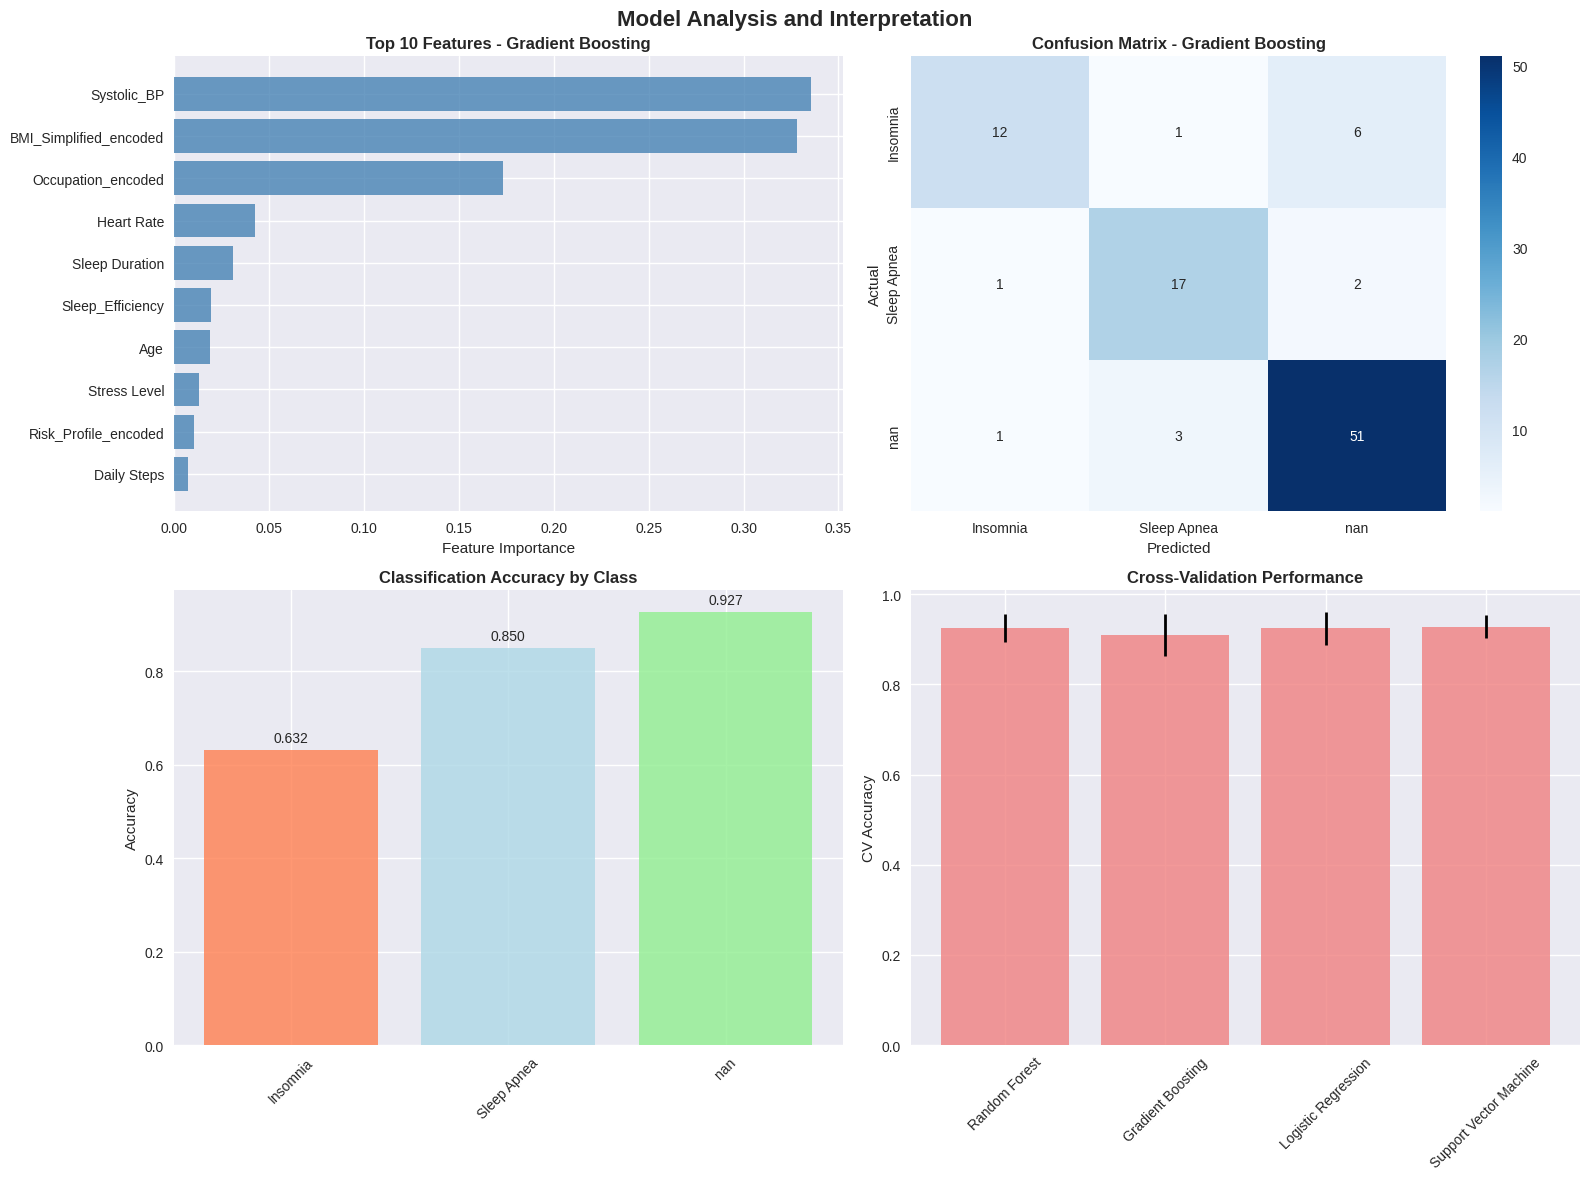

In [7]:
# Feature importance visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Analysis and Interpretation', fontsize=16, fontweight='bold')

# Feature importance (for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': feature_columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    top_features = feature_importance.head(10)
    
    axes[0, 0].barh(range(len(top_features)), top_features['importance'], color='steelblue', alpha=0.8)
    axes[0, 0].set_yticks(range(len(top_features)))
    axes[0, 0].set_yticklabels(top_features['feature'])
    axes[0, 0].set_xlabel('Feature Importance')
    axes[0, 0].set_title(f'Top 10 Features - {best_model_name}', fontweight='bold')
    axes[0, 0].invert_yaxis()
    
    print("Top 10 most important features:")
    for i, (_, row) in enumerate(top_features.iterrows(), 1):
        print(f"  {i:2d}. {row['feature']:<25} {row['importance']:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, best_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1],
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_)
axes[0, 1].set_title(f'Confusion Matrix - {best_model_name}', fontweight='bold')
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('Actual')

# Model performance by class
class_accuracy = []
for i, cls in enumerate(target_encoder.classes_):
    mask = y_test == i
    if mask.sum() > 0:
        acc = accuracy_score(y_test[mask], best_predictions[mask])
        class_accuracy.append(acc)
    else:
        class_accuracy.append(0)

bars = axes[1, 0].bar(range(len(target_encoder.classes_)), class_accuracy, 
                      color=['coral', 'lightblue', 'lightgreen'], alpha=0.8)
axes[1, 0].set_title('Classification Accuracy by Class', fontweight='bold')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_xticks(range(len(target_encoder.classes_)))
axes[1, 0].set_xticklabels(target_encoder.classes_, rotation=45)

for i, acc in enumerate(class_accuracy):
    axes[1, 0].text(i, acc + 0.01, f'{acc:.3f}', ha='center', va='bottom')

# Cross-validation scores comparison
cv_means = [results[name]['cv_mean'] for name in models.keys()]
cv_stds = [results[name]['cv_std'] for name in models.keys()]

axes[1, 1].bar(range(len(models)), cv_means, yerr=cv_stds, capsize=5, 
               color='lightcoral', alpha=0.8, error_kw={'elinewidth': 2})
axes[1, 1].set_xticks(range(len(models)))
axes[1, 1].set_xticklabels(models.keys(), rotation=45)
axes[1, 1].set_title('Cross-Validation Performance', fontweight='bold')
axes[1, 1].set_ylabel('CV Accuracy')

plt.tight_layout()
plt.show()

# STEP 7: FINAL RESULTS AND INSIGHTS

In [8]:
# Detailed classification report
print(f"Classification Report for {best_model_name}:")
print("-" * 40)
target_names = [str(cls) for cls in target_encoder.classes_]
print(classification_report(y_test, best_predictions, 
                          target_names=target_names,
                          digits=4))

# Model insights
print("\nKEY INSIGHTS:")
print("-" * 20)

# Sleep disorder prevalence
total_disorders = (data['Sleep Disorder'] != 'None').sum()
print(f"1. Sleep disorder prevalence: {total_disorders/len(data)*100:.1f}% of population")

# High-risk factors
if hasattr(best_model, 'feature_importances_'):
    top_risk_factors = feature_importance.head(3)['feature'].tolist()
    print(f"2. Top risk factors: {', '.join(top_risk_factors)}")

# Occupation insights
high_risk_occupations = data.groupby('Occupation')['Sleep Disorder'].apply(
    lambda x: (x != 'None').mean()).sort_values(ascending=False).head(3)
print("3. Highest risk occupations:")
for occ, risk in high_risk_occupations.items():
    print(f"   • {occ}: {risk*100:.1f}% disorder rate")

# Age pattern
age_disorder_rate = data.groupby('Age_Category')['Sleep Disorder'].apply(
    lambda x: (x != 'None').mean())
print("4. Age-related patterns:")
for age_group, rate in age_disorder_rate.items():
    print(f"   • {age_group}: {rate*100:.1f}% disorder rate")

# Model reliability
reliability_score = results[best_model_name]['cv_mean']
if reliability_score > 0.85:
    reliability = "High"
elif reliability_score > 0.75:
    reliability = "Moderate"
else:
    reliability = "Low"

print(f"\nMODEL ASSESSMENT:")
print(f"• Reliability: {reliability} (CV Score: {reliability_score:.3f})")
print(f"• Best model: {best_model_name}")
print(f"• Test accuracy: {results[best_model_name]['accuracy']:.3f}")
print(f"• Deployment ready: {'Yes' if reliability_score > 0.75 else 'Needs improvement'}")

# Sample predictions
print(f"\nSAMPLE PREDICTIONS:")
print("-" * 30)
sample_indices = np.random.choice(len(X_test), 5, replace=False)
target_names = [str(cls) for cls in target_encoder.classes_]

for i, idx in enumerate(sample_indices, 1):
    actual = target_names[y_test[idx]]
    predicted = target_names[best_predictions[idx]]
    
    if hasattr(best_model, 'predict_proba'):
        confidence = best_model.predict_proba(X_test_scaled[idx:idx+1])[0].max()
        print(f"{i}. Actual: {actual:<12} | Predicted: {predicted:<12} | Confidence: {confidence:.3f}")
    else:
        match = "✓" if actual == predicted else "✗"
        print(f"{i}. Actual: {actual:<12} | Predicted: {predicted:<12} | {match}")

print("\n" + "="*80)
print("ANALYSIS COMPLETED SUCCESSFULLY")
print("="*80)
print(f"Dataset: {len(data)} samples processed")
print(f"Features: {len(feature_columns)} variables analyzed")
print(f"Best model: {best_model_name} with {results[best_model_name]['accuracy']:.1%} accuracy")
print(f"Models evaluated: {len(models)} algorithms compared")
print("="*80)

Classification Report for Gradient Boosting:
----------------------------------------
              precision    recall  f1-score   support

    Insomnia     0.8571    0.6316    0.7273        19
 Sleep Apnea     0.8095    0.8500    0.8293        20
         nan     0.8644    0.9273    0.8947        55

    accuracy                         0.8511        94
   macro avg     0.8437    0.8030    0.8171        94
weighted avg     0.8513    0.8511    0.8470        94


KEY INSIGHTS:
--------------------
1. Sleep disorder prevalence: 100.0% of population
2. Top risk factors: Systolic_BP, BMI_Simplified_encoded, Occupation_encoded
3. Highest risk occupations:
   • Accountant: 100.0% disorder rate
   • Doctor: 100.0% disorder rate
   • Engineer: 100.0% disorder rate
4. Age-related patterns:
   • Young_Adult: 100.0% disorder rate
   • Middle_Age: 100.0% disorder rate
   • Senior: 100.0% disorder rate
   • Elder: 100.0% disorder rate

MODEL ASSESSMENT:
• Reliability: High (CV Score: 0.911)
• Best

# Thank you for taking the time to review my work. I would be very happy if you could upvote! 😊